📁 Diretório atual: /home/ematos/phd/pipeline_city/GRAFICOS
📁 Base do pipeline: /home/ematos/phd/pipeline_city/GRAFICOS/..
📄 Arquivo de entrada: /home/ematos/phd/pipeline_city/GRAFICOS/../INITIAL_NERS/OUTPUT_RESULTS/decision_final.csv
✅ Dataset carregado com sucesso!
Formato: (34990, 10)
         WORD   BIO1   BIO2          FILE  LINE  POSITION   BIO3 CONSENSUS  \
0  Monumentos      O      O  Abrantes.txt     1         1      O         O   
1           :      O      O  Abrantes.txt     1         2      O         O   
2    Abrantes  B-PER  B-PER  Abrantes.txt     1         3  B-LOC     B-PER   
3           é      O      O  Abrantes.txt     1         4      O         O   
4         uma      O      O  Abrantes.txt     1         5      O         O   

     WTA ENTITY  
0      O      O  
1      O      O  
2  B-PER    ENT  
3      O      O  
4      O      O  

📊 Resultados:
- Total de palavras: 31088
- Total de entidades 'ENT': 10619

📈 Porcentagens:
- Palavras (Total): 100.00%
- Entidades: 3

/tmp/ipykernel_66781/3088986818.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Categoria', y='Porcentagem', data=df_plot, palette='viridis')


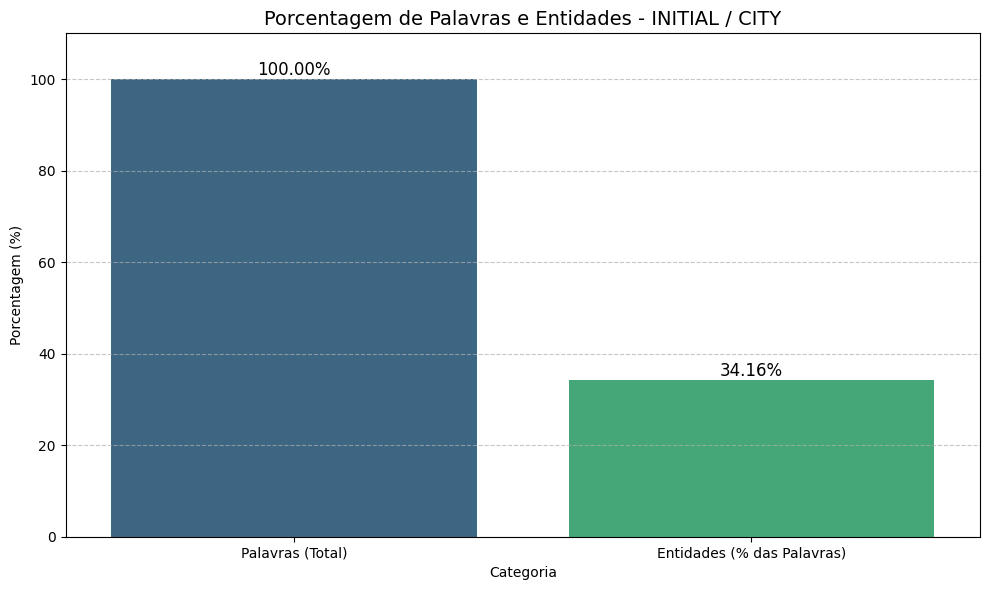

In [1]:
#!/usr/bin/env python
# coding: utf-8

"""
Análise de Palavras e Entidades em Dataset NER (INITIAL_NERS)
Este script realiza:
- Leitura de arquivo CSV de resultados
- Contagem de palavras válidas (sem pontuação)
- Contagem de entidades "ENT"
- Geração de gráfico com a porcentagem de entidades em relação às palavras
"""

# ======================
# 1. Imports e Configuração Inicial
# ======================
import os
import sys
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# 2. Caminhos e Diretórios
# ======================
# Determina o diretório atual e configura o caminho base
working_dir = os.getcwd()
parts = working_dir.split("/")

if parts[-1].startswith("pipeline"):  # Se está no diretório do pipeline
    pipeline = working_dir
else:
    pipeline = "/".join(parts[:-1])

base = pipeline
sys.path.append(base)

from config.configsite import *  # Parâmetros customizados do pipeline

# Define caminho do arquivo de entrada
pipeline_base_dir = working_dir if os.path.basename(working_dir).startswith("pipeline") else os.path.join(working_dir, '..')
output_results_dir = os.path.join(pipeline_base_dir, 'INITIAL_NERS', 'OUTPUT_RESULTS')
filename_results = 'decision_final.csv'
file_path_results = os.path.join(output_results_dir, filename_results)

print(f"📁 Diretório atual: {working_dir}")
print(f"📁 Base do pipeline: {pipeline_base_dir}")
print(f"📄 Arquivo de entrada: {file_path_results}")

# ======================
# 3. Leitura do Dataset
# ======================
try:
    data_df = pd.read_csv(file_path_results, sep='\t')
    print("✅ Dataset carregado com sucesso!")
    print(f"Formato: {data_df.shape}")
    print(data_df.head())
except FileNotFoundError:
    print(f"❌ Erro: arquivo '{file_path_results}' não encontrado.")
    data_df = None

# ======================
# 4. Funções Utilitárias
# ======================
def clean_word(word_str: str) -> str:
    """Remove pontuações de uma palavra e retorna string limpa."""
    if pd.isna(word_str):
        return ""
    return str(word_str).translate(str.maketrans('', '', '.,:="'))

def count_words_and_entities(df: pd.DataFrame) -> tuple[int, int]:
    """Conta palavras e entidades 'ENT' em um DataFrame."""
    if df is None:
        return 0, 0

    total_words = 0
    total_entities = 0

    if 'WORD' in df.columns:
        total_words = df['WORD'].apply(clean_word).astype(bool).sum()
    else:
        print("⚠️ Coluna 'WORD' não encontrada.")

    if 'ENTITY' in df.columns:
        total_entities = df[df['ENTITY'] == 'ENT'].shape[0]
    else:
        print("⚠️ Coluna 'ENTITY' não encontrada.")

    return total_words, total_entities

# ======================
# 5. Análise e Geração de Gráfico
# ======================
if data_df is not None:
    num_words, num_entities = count_words_and_entities(data_df)

    print("\n📊 Resultados:")
    print(f"- Total de palavras: {num_words}")
    print(f"- Total de entidades 'ENT': {num_entities}")

    percent_words = 100.0
    percent_entities = (num_entities / num_words) * 100 if num_words > 0 else 0.0

    print(f"\n📈 Porcentagens:")
    print(f"- Palavras (Total): {percent_words:.2f}%")
    print(f"- Entidades: {percent_entities:.2f}%")

    # Dados para plotagem
    df_plot = pd.DataFrame({
        'Categoria': ['Palavras (Total)', 'Entidades (% das Palavras)'],
        'Porcentagem': [percent_words, percent_entities]
    })

    # ======================
    # 6. Gráfico de Barras
    # ======================
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Categoria', y='Porcentagem', data=df_plot, palette='viridis')

    for index, row in df_plot.iterrows():
        plt.text(index, row['Porcentagem'], f'{row["Porcentagem"]:.2f}%',
                 color='black', ha="center", va='bottom', fontsize=12)

    plt.title(f'Porcentagem de Palavras e Entidades - INITIAL / {datagraph}', fontsize=14)
    plt.ylabel('Porcentagem (%)')
    plt.xlabel('Categoria')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    max_y = max(percent_words, percent_entities)
    plt.ylim(0, max_y * 1.1 if max_y > 0 else 100)
    plt.tight_layout()

📁 Diretório atual: /home/ematos/phd/pipeline_city/GRAFICOS
📁 Base do pipeline: /home/ematos/phd/pipeline_city/GRAFICOS/..
📄 Arquivo de entrada: /home/ematos/phd/pipeline_city/GRAFICOS/../ENTITY_DETECTOR_BY_BERT/OUTPUT_RESULTS/output_bert_final_DATASET_CITY.csv
✅ Dataset carregado com sucesso!
Formato: (36011, 9)
  Unnamed: 0  Sentence #        Word       Tag POS  LINE  POSITION  \
0          0  Sentence:1  Monumentos         O   X   1.0       1.0   
1          1  Sentence:1           :         O   X   1.0       2.0   
2          2  Sentence:1    Abrantes  B-ENTITY   X   1.0       3.0   
3          3  Sentence:1           é         O   X   1.0       4.0   
4          4  Sentence:1         uma         O   X   1.0       5.0   

           FILE       BIO  
0  Abrantes.txt         O  
1  Abrantes.txt         O  
2  Abrantes.txt  B-ENTITY  
3  Abrantes.txt         O  
4  Abrantes.txt         O  

📊 Resultados:
- Total de palavras: 31491
- Total de entidades 'ENT': 10748

📈 Porcentagens:
- Pa

/tmp/ipykernel_66781/704864469.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Categoria', y='Porcentagem', data=df_plot, palette='viridis')


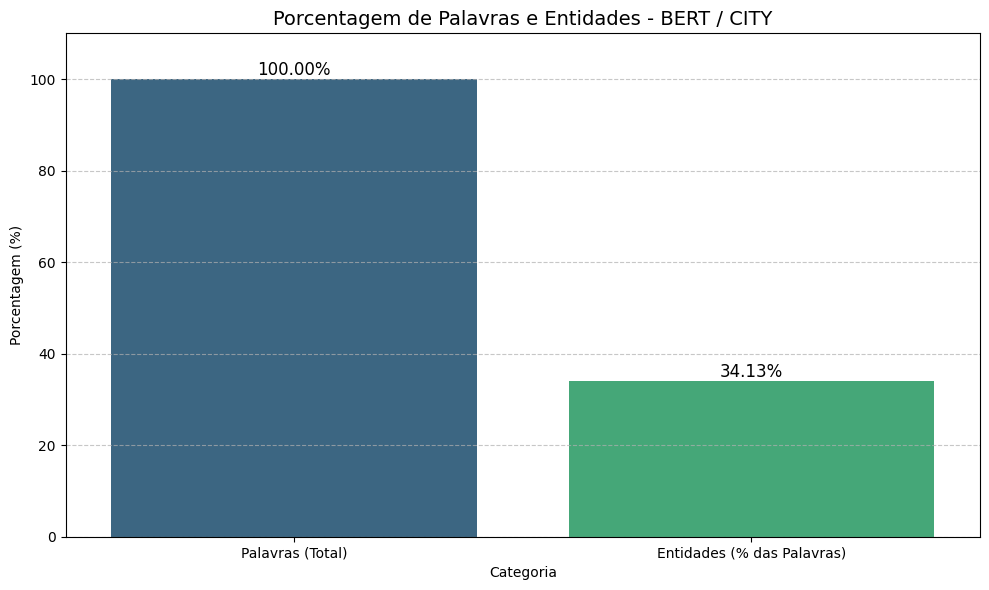

In [2]:
#!/usr/bin/env python
# coding: utf-8

"""
Análise de Palavras e Entidades em Dataset NER com BERT
Este script:
- Lê um arquivo com colunas 'Word' e 'BIO'
- Conta palavras e entidades
- Calcula a porcentagem de entidades sobre palavras
- Gera e salva gráfico comparativo
"""

# ======================
# 1. Imports e Configuração Inicial
# ======================
import os
import sys
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# 2. Caminhos e Diretórios
# ======================
working_dir = os.getcwd()
parts = working_dir.split("/")

pipeline = working_dir if parts[-1].startswith("pipeline") else "/".join(parts[:-1])
base = pipeline
sys.path.append(base)

from config.configsite import *  # Importa parâmetros do projeto

pipeline_base_dir = working_dir if os.path.basename(working_dir).startswith("pipeline") else os.path.join(working_dir, '..')
output_results_dir = os.path.join(pipeline_base_dir, 'ENTITY_DETECTOR_BY_BERT', 'OUTPUT_RESULTS')
filename_results = f'output_bert_final_{dataset}.csv'
file_path_results = os.path.join(output_results_dir, filename_results)

print(f"📁 Diretório atual: {working_dir}")
print(f"📁 Base do pipeline: {pipeline_base_dir}")
print(f"📄 Arquivo de entrada: {file_path_results}")

# ======================
# 3. Leitura do Dataset
# ======================
try:
    data_df = pd.read_csv(file_path_results, sep='\t')
    print("✅ Dataset carregado com sucesso!")
    print(f"Formato: {data_df.shape}")
    print(data_df.head())
except FileNotFoundError:
    print(f"❌ Erro: arquivo '{file_path_results}' não encontrado.")
    data_df = None

# ======================
# 4. Funções Utilitárias
# ======================
def clean_word(word_str: str) -> str:
    """Remove pontuações de uma palavra e retorna string limpa."""
    if pd.isna(word_str):
        return ""
    return str(word_str).translate(str.maketrans('', '', '.,:="'))

def count_words_and_entities(df: pd.DataFrame) -> tuple[int, int]:
    """Conta palavras válidas e entidades no dataset."""
    if df is None:
        return 0, 0

    total_words = 0
    total_entities = 0

    if 'Word' in df.columns:
        total_words = df['Word'].apply(clean_word).astype(bool).sum()
    else:
        print("⚠️ Coluna 'Word' não encontrada.")

    if 'BIO' in df.columns:
        total_entities = df[df['BIO'].isin(['B-ENTITY', 'I-ENTITY'])].shape[0]
    else:
        print("⚠️ Coluna 'BIO' não encontrada.")

    return total_words, total_entities

# ======================
# 5. Análise e Geração de Gráfico
# ======================
if data_df is not None:
    num_words, num_entities = count_words_and_entities(data_df)

    print("\n📊 Resultados:")
    print(f"- Total de palavras: {num_words}")
    print(f"- Total de entidades 'ENT': {num_entities}")

    percent_words = 100.0
    percent_entities = (num_entities / num_words * 100) if num_words > 0 else 0.0

    print(f"\n📈 Porcentagens:")
    print(f"- Palavras (Total): {percent_words:.2f}%")
    print(f"- Entidades: {percent_entities:.2f}%")

    df_plot = pd.DataFrame({
        'Categoria': ['Palavras (Total)', 'Entidades (% das Palavras)'],
        'Porcentagem': [percent_words, percent_entities]
    })

    # ======================
    # 6. Gráfico de Barras
    # ======================
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Categoria', y='Porcentagem', data=df_plot, palette='viridis')

    for index, row in df_plot.iterrows():
        plt.text(index, row['Porcentagem'], f'{row["Porcentagem"]:.2f}%',
                 color='black', ha="center", va='bottom', fontsize=12)

    plt.title(f'Porcentagem de Palavras e Entidades - BERT / {datagraph}', fontsize=14)
    plt.ylabel('Porcentagem (%)')
    plt.xlabel('Categoria')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    max_y = max(percent_words, percent_entities)
    plt.ylim(0, max_y * 1.1 if max_y > 0 else 100)
    plt.tight_layout()

📁 Diretório atual: /home/ematos/phd/pipeline_city/GRAFICOS
📁 Base do pipeline: /home/ematos/phd/pipeline_city/GRAFICOS/..
📄 Arquivo de entrada: /home/ematos/phd/pipeline_city/GRAFICOS/../MAPPER_ENTITY2CLASSES/OUTPUT_RESULTS/results_mapper_by_word.csv
✅ Dataset carregado com sucesso!
Formato: (34028, 6)
    id_file  Line  POSITION        WORD       NER  \
0  Abrantes   1.0       1.0  Monumentos         O   
1  Abrantes   1.0       2.0           :         O   
2  Abrantes   1.0       4.0    Abrantes  B-ENTITY   
3  Abrantes   1.0       4.0           é         O   
4  Abrantes   1.0       5.0         uma         O   

                                   MAPPER  
0                                       O  
1                                       O  
2  B-PÁGINA_DE_DESAMBIGUAÇÃO_DA_WIKIMEDIA  
3                                       O  
4                                       O  

📊 Resultados:
- Total de palavras: 29508
- Total de entidades 'ENT': 8765

📈 Porcentagens:
- Palavras (Total): 1

/tmp/ipykernel_66781/3617367016.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Categoria', y='Porcentagem', data=df_plot, palette='viridis')


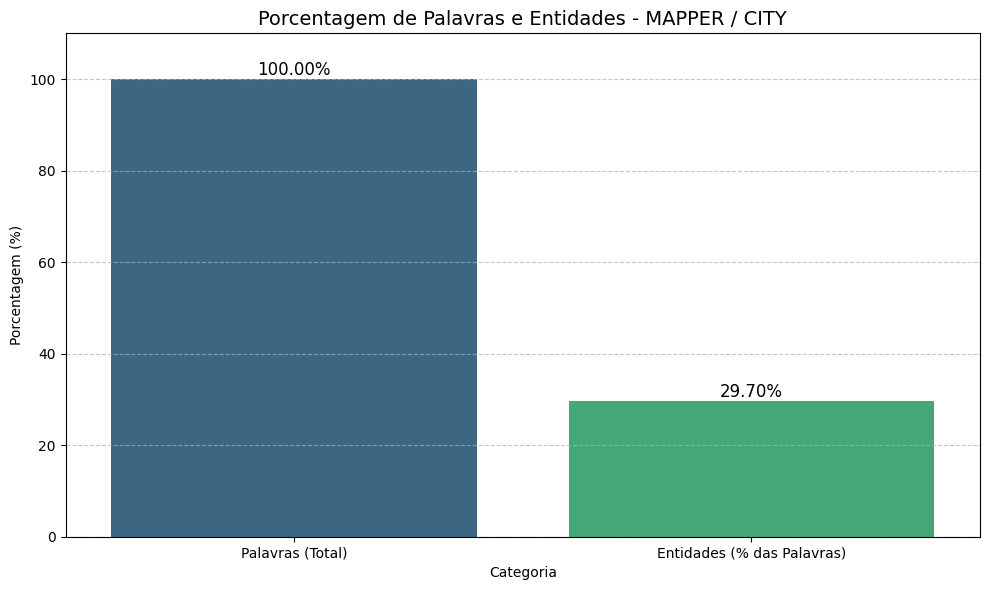

In [3]:
#!/usr/bin/env python
# coding: utf-8

"""
Análise de Palavras e Entidades em Dataset NER com MAPPER_ENTITY2CLASSES
Este script:
- Lê arquivo de resultados com colunas 'WORD' e 'NER'
- Conta palavras válidas e entidades 'ENT'
- Calcula porcentagem de entidades sobre total de palavras
- Gera e salva gráfico de barras comparativo
"""

# ======================
# 1. Imports e Configuração Inicial
# ======================
import os
import sys
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# 2. Caminhos e Diretórios
# ======================
working_dir = os.getcwd()
parts = working_dir.split("/")

pipeline = working_dir if parts[-1].startswith("pipeline") else "/".join(parts[:-1])
base = pipeline
sys.path.append(base)

from config.configsite import *  # Parâmetros do projeto

pipeline_base_dir = working_dir if os.path.basename(working_dir).startswith("pipeline") else os.path.join(working_dir, '..')
output_results_dir = os.path.join(pipeline_base_dir, 'MAPPER_ENTITY2CLASSES', 'OUTPUT_RESULTS')
filename_results = 'results_mapper_by_word.csv'
file_path_results = os.path.join(output_results_dir, filename_results)

print(f"📁 Diretório atual: {working_dir}")
print(f"📁 Base do pipeline: {pipeline_base_dir}")
print(f"📄 Arquivo de entrada: {file_path_results}")

# ======================
# 3. Leitura do Dataset
# ======================
try:
    data_df = pd.read_csv(file_path_results, sep='\t')
    print("✅ Dataset carregado com sucesso!")
    print(f"Formato: {data_df.shape}")
    print(data_df.head())
except FileNotFoundError:
    print(f"❌ Erro: arquivo '{file_path_results}' não encontrado.")
    data_df = None

# ======================
# 4. Funções Utilitárias
# ======================
def clean_word(word_str: str) -> str:
    """Remove pontuações de uma palavra e retorna string limpa."""
    if pd.isna(word_str):
        return ""
    return str(word_str).translate(str.maketrans('', '', '.,:="'))

def count_words_and_entities(df: pd.DataFrame) -> tuple[int, int]:
    """Conta palavras válidas e entidades 'ENT' no dataset."""
    if df is None:
        return 0, 0

    total_words = 0
    total_entities = 0

    if 'WORD' in df.columns:
        total_words = df['WORD'].apply(clean_word).astype(bool).sum()
    else:
        print("⚠️ Coluna 'WORD' não encontrada.")

    if 'NER' in df.columns:
        total_entities = df[df['NER'].isin(['B-ENTITY', 'I-ENTITY'])].shape[0]
    else:
        print("⚠️ Coluna 'NER' não encontrada.")

    return total_words, total_entities

# ======================
# 5. Análise e Geração de Gráfico
# ======================
if data_df is not None:
    num_words, num_entities = count_words_and_entities(data_df)

    print("\n📊 Resultados:")
    print(f"- Total de palavras: {num_words}")
    print(f"- Total de entidades 'ENT': {num_entities}")

    percent_words = 100.0
    percent_entities = (num_entities / num_words * 100) if num_words > 0 else 0.0

    print(f"\n📈 Porcentagens:")
    print(f"- Palavras (Total): {percent_words:.2f}%")
    print(f"- Entidades: {percent_entities:.2f}%")

    df_plot = pd.DataFrame({
        'Categoria': ['Palavras (Total)', 'Entidades (% das Palavras)'],
        'Porcentagem': [percent_words, percent_entities]
    })

    # ======================
    # 6. Gráfico de Barras
    # ======================
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Categoria', y='Porcentagem', data=df_plot, palette='viridis')

    for index, row in df_plot.iterrows():
        plt.text(index, row['Porcentagem'], f'{row["Porcentagem"]:.2f}%',
                 color='black', ha="center", va='bottom', fontsize=12)

    plt.title(f'Porcentagem de Palavras e Entidades - MAPPER / {datagraph}', fontsize=14)
    plt.ylabel('Porcentagem (%)')
    plt.xlabel('Categoria')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    max_y = max(percent_words, percent_entities)
    plt.ylim(0, max_y * 1.1 if max_y > 0 else 100)
    plt.tight_layout()

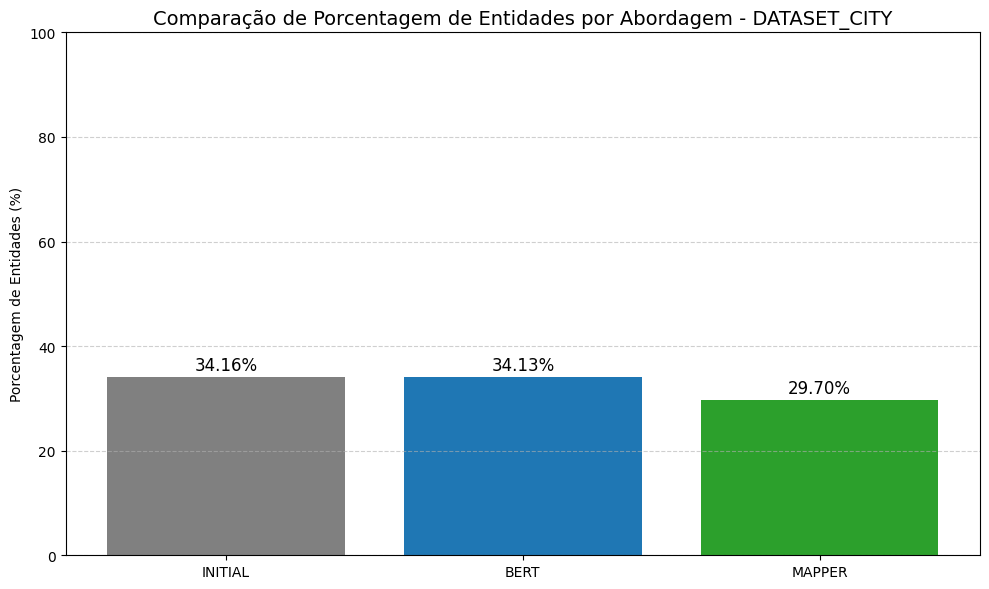


📊 Tabela Comparativa:
Abordagem  Palavras  Entidades  Porcentagem de Entidades (%)
  INITIAL     31088      10619                     34.157874
     BERT     31491      10748                     34.130386
   MAPPER     29508       8765                     29.703809

✅ Gráfico salvo em: grafico_comparativo_abordagens_DATASET_CITY.png


In [4]:
#!/usr/bin/env python
# coding: utf-8

"""
Pipeline Unificado para Comparação das Abordagens INITIAL, BERT e MAPPER
Conta palavras e entidades em arquivos CSV e gera gráfico comparativo.
"""

# ======================
# 1. Imports
# ======================
import os
import pandas as pd
import matplotlib.pyplot as plt

# ======================
# 2. Funções auxiliares
# ======================
def clean_word(word_str: str) -> str:
    if pd.isna(word_str):
        return ""
    return str(word_str).translate(str.maketrans('', '', '.,:="'))

def count_words_and_entities(df, word_col, ent_col, ent_values=['ENT', 'B-ENTITY', 'I-ENTITY']):
    if df is None or word_col not in df.columns or ent_col not in df.columns:
        return 0, 0
    total_words = df[word_col].apply(clean_word).astype(bool).sum()
    total_entities = df[df[ent_col].isin(ent_values)].shape[0]
    return total_words, total_entities

# ======================
# 3. Configurações de arquivos
# ======================
configs = [
    {
        'name': 'INITIAL',
        'file': 'INITIAL_NERS/OUTPUT_RESULTS/decision_final.csv',
        'word_col': 'WORD',
        'ent_col': 'ENTITY'
    },
    {
        'name': 'BERT',
        'file': f'ENTITY_DETECTOR_BY_BERT/OUTPUT_RESULTS/output_bert_final_{dataset}.csv',
        'word_col': 'Word',
        'ent_col': 'BIO'
    },
    {
        'name': 'MAPPER',
        'file': 'MAPPER_ENTITY2CLASSES/OUTPUT_RESULTS/results_mapper_by_word.csv',
        'word_col': 'WORD',
        'ent_col': 'NER'
    }
]

# Diretório base corrigido (removendo /GRAFICOS/ se estiver presente)
base_dir = os.getcwd()
if "GRAFICOS" in base_dir:
    base_dir = base_dir.split("GRAFICOS")[0]
    base_dir = base_dir.rstrip("/")

# ======================
# 4. Processamento das abordagens
# ======================
resultados = []

for cfg in configs:
    path = os.path.join(base_dir, cfg['file'])
    try:
        df = pd.read_csv(path, sep='\t')
        total_words, total_entities = count_words_and_entities(df, cfg['word_col'], cfg['ent_col'])
        percentual = (total_entities / total_words * 100) if total_words > 0 else 0.0
        resultados.append({
            'Abordagem': cfg['name'],
            'Palavras': total_words,
            'Entidades': total_entities,
            'Porcentagem de Entidades (%)': percentual
        })
    except FileNotFoundError:
        print(f"❌ Arquivo não encontrado: {path}")
        resultados.append({
            'Abordagem': cfg['name'],
            'Palavras': 0,
            'Entidades': 0,
            'Porcentagem de Entidades (%)': 0.0
        })

# ======================
# 5. Geração do gráfico
# ======================
df_resultado = pd.DataFrame(resultados)

plt.figure(figsize=(10, 6))
bars = plt.bar(df_resultado["Abordagem"], df_resultado["Porcentagem de Entidades (%)"],
               color=["#808080", "#1f77b4", "#2ca02c"])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, yval + 0.5,
             f'{yval:.2f}%', ha='center', va='bottom', fontsize=12)

plt.title(f"Comparação de Porcentagem de Entidades por Abordagem - {dataset}", fontsize=14)
plt.ylabel("Porcentagem de Entidades (%)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylim(0, 100)
plt.tight_layout()

# ======================
# 6. Salvar e exibir
# ======================
output_graph = f"grafico_comparativo_abordagens_{dataset}.png"
plt.savefig(output_graph, bbox_inches='tight')
plt.show()

print("\n📊 Tabela Comparativa:")
print(df_resultado.to_string(index=False))
print(f"\n✅ Gráfico salvo em: {output_graph}")
